# Chapter 09 - Text Processing and Multiclass Classification
## Converting Text into Features for Machine Learning
Based on scikit-learn Cookbook. This notebook explores vectorization, TF-IDF, and text classification with more diverse visualizations.

## Objective
Understand how raw text is transformed into numeric features and used for multiclass classification.

## Theory Introduction
Machine learning models require numeric input. Text preprocessing converts documents into vectors using methods such as Bag of Words and TF-IDF.

TF-IDF gives higher weight to informative words and lower weight to common words.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
plt.style.use('ggplot')

## 1. Load Dataset

In [2]:
categories = ['sci.space','rec.sport.baseball','comp.graphics']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers','footers','quotes'))
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.25, random_state=42, stratify=data.target)

Three categories are selected to demonstrate multiclass text classification.

## 2. Class Distribution (Pie Chart)

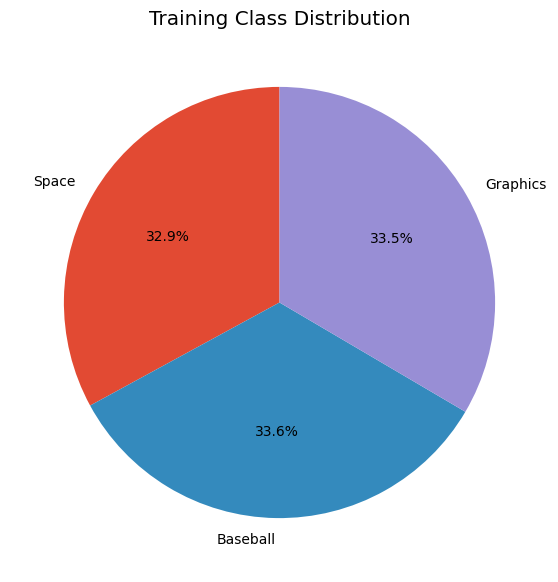

In [3]:
counts = np.bincount(y_train)
labels = ['Space','Baseball','Graphics']
plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Training Class Distribution')
plt.show()

**Description:** This pie chart shows class balance in the training data. Balanced classes help fair model learning.

## 3. CountVectorizer Example

In [4]:
cv = CountVectorizer(stop_words='english', max_features=15)
X_counts = cv.fit_transform(X_train)
words = cv.get_feature_names_out()
freq = np.asarray(X_counts.sum(axis=0)).ravel()

## 4. Top Frequent Words (Horizontal Bar Chart)

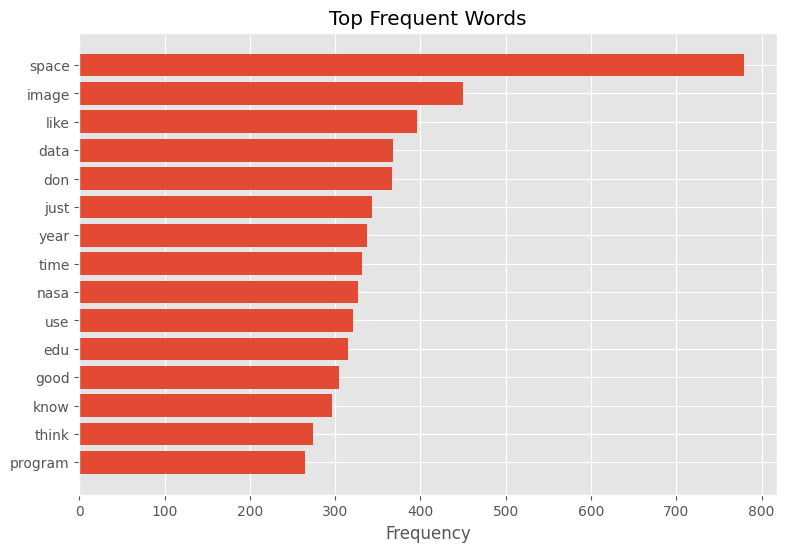

In [5]:
idx = np.argsort(freq)
plt.figure(figsize=(9,6))
plt.barh(words[idx], freq[idx])
plt.title('Top Frequent Words')
plt.xlabel('Frequency')
plt.show()

**Description:** Common words after stop-word removal can reveal dominant themes in the corpus.

## 5. TF-IDF + Naive Bayes Model

In [6]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)
model = MultinomialNB()
model.fit(Xtr,y_train)
pred = model.predict(Xte)
acc = accuracy_score(y_test,pred)
print('Accuracy:', round(acc,4))

Accuracy: 0.9189


## 6. Confusion Matrix Heatmap

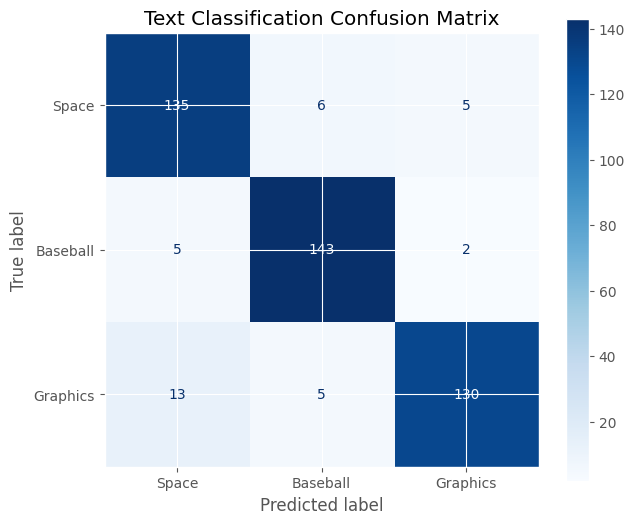

In [7]:
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=labels,ax=ax,cmap='Blues')
plt.title('Text Classification Confusion Matrix')
plt.show()

**Description:** The confusion matrix shows which categories are easier or harder to distinguish.

## 7. Document Length Distribution

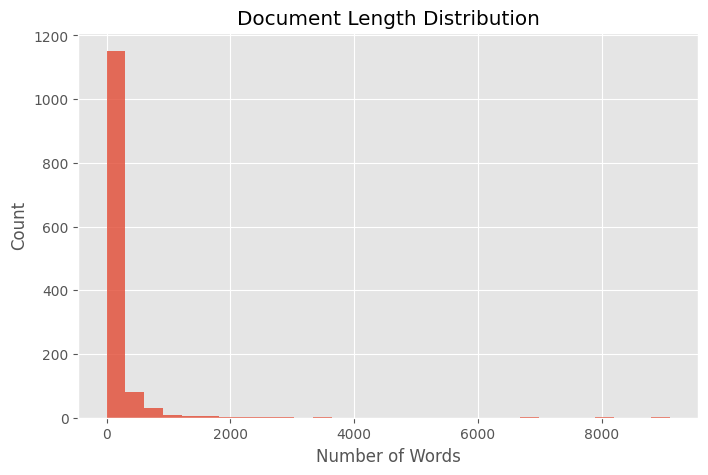

In [8]:
lengths = [len(doc.split()) for doc in X_train if len(doc.split())>0]
plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30, alpha=0.8)
plt.title('Document Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

**Description:** Document lengths vary significantly. Extremely short or long texts may affect model quality.

## Important Theory Concepts
- **Bag of Words:** Counts word occurrences.
- **TF-IDF:** Weights informative terms more strongly.
- **Stop Words:** Common words often removed.
- **Sparse Matrix:** Efficient representation of text vectors.
- **Naive Bayes:** Fast probabilistic classifier for text.

## Interpretation of Results
Text classification performance depends on preprocessing quality, feature representation, and class similarity. TF-IDF often improves results over raw counts.

## Summary
Text data can be transformed into machine learning features using vectorization techniques. Even simple models like Naive Bayes often perform strongly on document classification tasks.

## Conclusion
For many NLP baseline tasks, TF-IDF + Naive Bayes is fast, effective, and easy to interpret.